# VM.AI Duration — User Input & AI Predictions

## Why Make Another Model?

Users consistently overshoot or undershoot how long a task takes. A "hard workout" might be 30 minutes or 90 depending on difficulty, location travel, and deadline pressure. A "quick meeting" scheduled for 30 minutes routinely runs 60.

T5 struggles with numeric fields — it generates tokens, not continuous values. Duration has the same architectural mismatch as difficulty/importance, plus:

- **Wide range** — durations span 1–600+ minutes
- **Context interactions** — text alone doesn't capture how difficulty, location, and deadline combine to affect duration
- **Limited Dataset** - the limited dataset at hand doesn't give the model enough variety to learn most patterns properly

The solution: a standalone **XGBoost regressor** on tabular features, independent of T5 and the RidgeCV regressors.

## Data Generation

`VMAI_DURATION_Data.csv` — ~10,000 rows, ~20% undoable (`real_duration = 0`).

### Columns

| Column | Type | Description |
|---|---|---|
| difficulty | float [0,1] | Task difficulty |
| importance | float [0,1] | Task importance |
| scheduled_duration | int (min) | User's planned duration |
| category | str | work, health, personal, errand, social, study |
| location | str | home, office, gym, cafe, store, outdoor |
| time_difference | float (hours) | deadline_hour − current_hour. −1 = no deadline |
| real_duration | float (min) | Target: actual time the task took |

### Generation Rules

Due to time constraints and access to data, the training dataset was generated by using the following rules:

- Base = scheduled × random(0.95, 1.05)
- Difficulty > 0.6 → up to 1.4×; < 0.4 → 0.76×
- Importance > 0.7 → up to 1.21×; < 0.3 → 0.65×
- Category multiplier (health 1.15×, personal 0.88×, etc.)
- Travel overhead (outdoor +25 min, home 0 min)
- Deadline: < 40% time remaining → undoable; < 100% → −12–25%
- Gaussian noise, capped at 3.5× scheduled

## Feature Pipeline

Training: `ColumnTransformer(SimpleImputer(fill_value=-1) + OneHotEncoder)` → 16 features (4 numeric + 12 one-hot).

Inference: manual one-hot using `duration_info.json` — no sklearn pipeline.

## Model Comparison

| Model | Result |
|---|---|
| Ridge | Linear — misses interactions |
| RandomForest | Good but plateaued |
| **XGBoost** | **Best MAE + R²** |

### Hyperparameter Tuning

GridSearchCV 5-fold over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`.

Learning rate sensitivity: U-shaped curve — 0.01 underfits, 0.2 diverges, **0.03 optimal**.

Learning curve: diminishing returns past ~60% of data — dataset size is adequate.

### Undoable Classification

The program detects when a task is `undoable` (i.e. there isn't enough time left for the task)

## Performance

- **Test MAE**: ~3.9 min (synthetic — expect ~15–25 min on real data)
- **R²**: ~0.98
- **5-fold CV MAE**: consistent within ±0.1 — no overfitting
- **Residuals**: roughly normal, centered at 0
- **Top features**: `scheduled_duration`, `difficulty`, `importance`, `time_difference`

## Export

Retrain on all data. Save:
- `duration_predictor.ubj` — XGBoost native (version-independent)
- `duration_info.json` — category order for manual one-hot at inference


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime

import xgboost as xgb


In [2]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
})


In [3]:
def save_fig(name):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/{name}_{timestamp}.png", dpi=150, bbox_inches="tight")
    print(f"  Saved: plots/{name}_{timestamp}.png")


In [4]:
train = pd.read_csv("VMAI_DURATION_Data.csv")

print("Shape:", train.shape)
train.head()


Shape: (10000, 8)


,difficulty,importance,scheduled_duration,category,location,fixed_time,time_difference,real_duration
0,0.280,0.560,44,study,cafe,22:15,0.25,0.0
1,0.812,0.386,47,health,home,NaN,-1.00,68.0
2,0.401,0.386,35,work,home,23:45,3.75,38.9
3,0.317,0.444,22,errand,store,NaN,-1.00,30.0
4,0.510,0.220,30,personal,home,23:00,4.00,29.1


  Saved: plots/distributions_2026-05-28_12-48.png


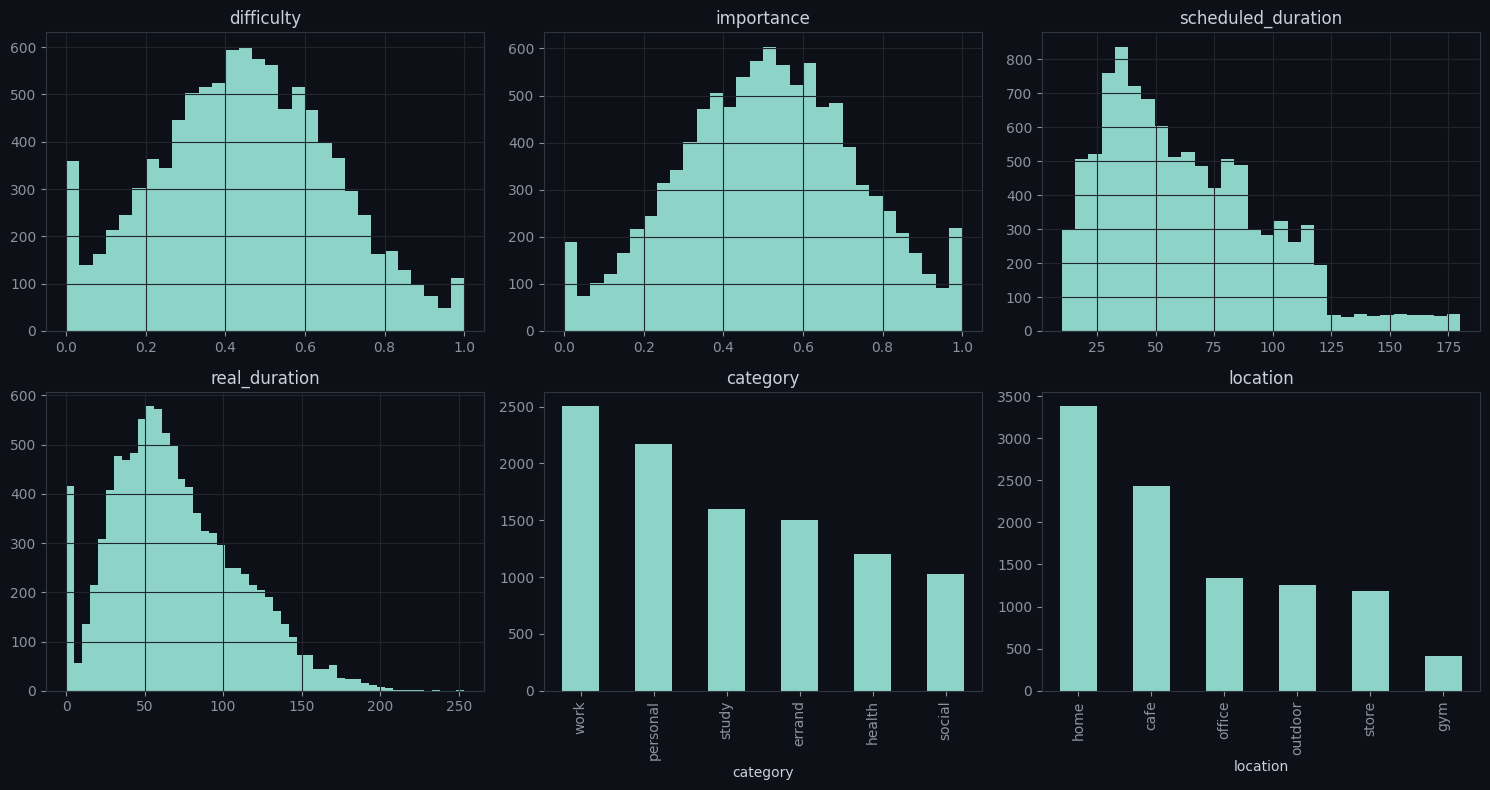

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

train["difficulty"].hist(bins=30, ax=axes[0, 0])
axes[0, 0].set_title("difficulty")

train["importance"].hist(bins=30, ax=axes[0, 1])
axes[0, 1].set_title("importance")

train["scheduled_duration"].hist(bins=30, ax=axes[0, 2])
axes[0, 2].set_title("scheduled_duration")

train["real_duration"].hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title("real_duration")

train["category"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("category")

train["location"].value_counts().plot(kind="bar", ax=axes[1, 2])
axes[1, 2].set_title("location")

plt.tight_layout()
save_fig("distributions")


  Saved: plots/cat_loc_effects_2026-05-28_12-48.png


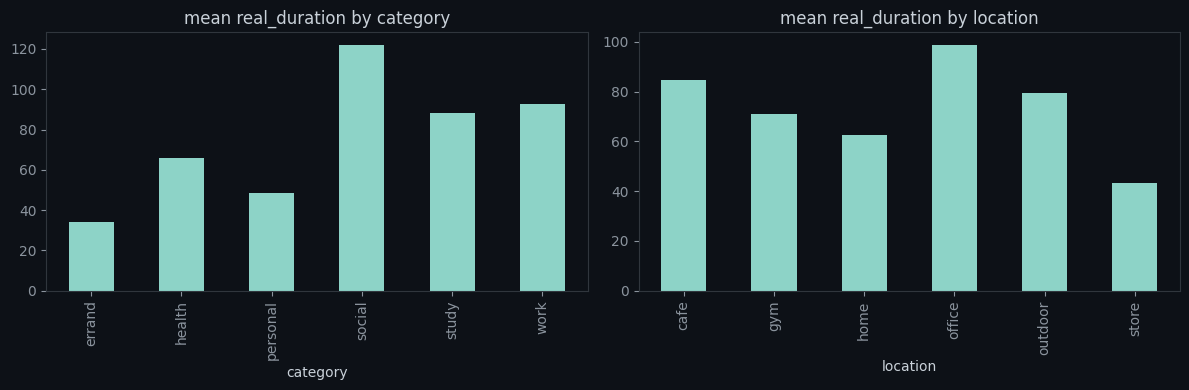

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nz = train[train["real_duration"] > 0]

nz.groupby("category")["real_duration"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("mean real_duration by category")

nz.groupby("location")["real_duration"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("mean real_duration by location")

plt.tight_layout()
save_fig("cat_loc_effects")


  Saved: plots/correlation_2026-05-28_12-48.png


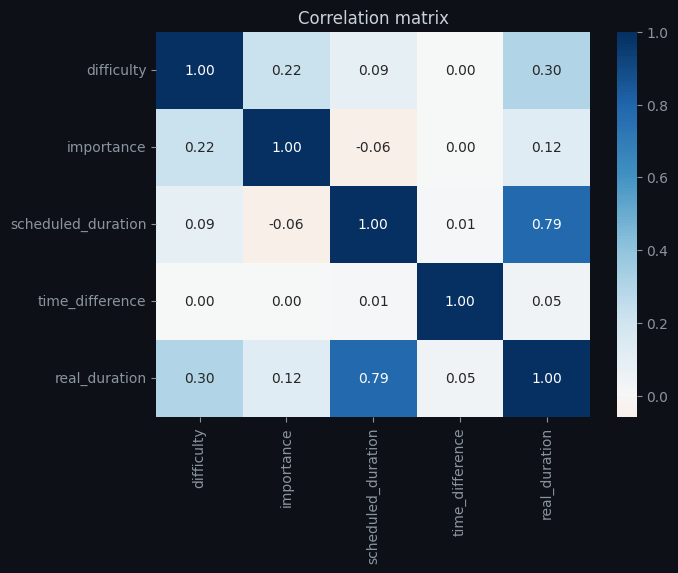

In [7]:
num_cols = [
    "difficulty",
    "importance",
    "scheduled_duration",
    "time_difference",
    "real_duration",
]

corr = train[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0, fmt=".2f")
plt.title("Correlation matrix")
save_fig("correlation")


In [8]:
X = train.drop("real_duration", axis=1)
y = train["real_duration"]

num_feats = [
    "difficulty",
    "importance",
    "scheduled_duration",
    "time_difference",
]

cat_feats = [
    "category",
    "location",
]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
])

cat_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_feats),
    ("cat", cat_pipe, cat_feats),
])

X_proc = preprocessor.fit_transform(X)

feat_names = (
    num_feats
    + list(
        preprocessor
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_feats)
    )
)

print(f"Features: {X_proc.shape[1]} "
      f"({len(num_feats)} numeric + {X_proc.shape[1] - len(num_feats)} encoded)")


Features: 16 (4 numeric + 12 encoded)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

baseline = np.full_like(y, y.mean())
print(f"Baseline MAE: {mean_absolute_error(y, baseline):.4f}  "
      f"R2: {r2_score(y, baseline):.4f}")


Train: 8000  Test: 2000
Baseline MAE: 32.2708  R2: 0.0000


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [12:48:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


       model       MAE       R2
       Ridge 10.242275 0.735415
RandomForest  5.474199 0.947549
     XGBoost  4.417089 0.974837
  Saved: plots/model_comparison_2026-05-28_12-48.png


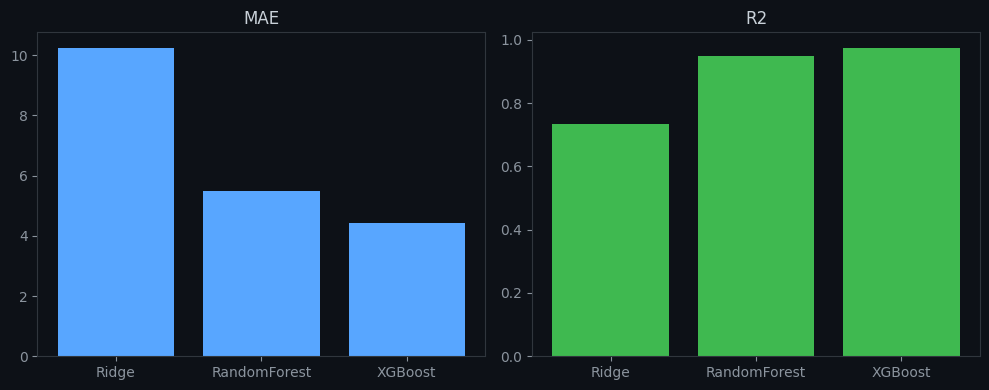

In [10]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        device="cuda",
    ),
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, p),
        "R2": r2_score(y_test, p),
    })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#58a6ff", "#3fb950", "#f0883e"]

for i, metric in enumerate(["MAE", "R2"]):
    axes[i].bar(res_df["model"], res_df[metric], color=colors[i])
    axes[i].set_title(metric)

plt.tight_layout()
save_fig("model_comparison")


In [ ]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [6, 10, 14],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

gs = xgb.XGBRegressor(random_state=42, device="cuda")
grid = GridSearchCV(
    gs,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV MAE: {-grid.best_score_:.4f}")

best_params = grid.best_params_


In [16]:
best_params = {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.7}

  Saved: plots/lr_sensitivity_2026-05-28_12-49.png


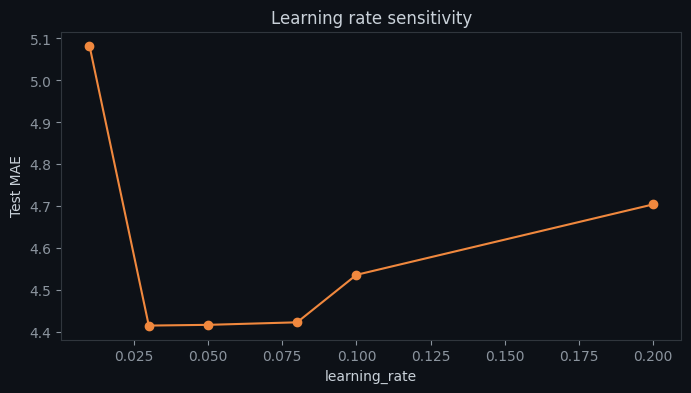

In [14]:
lrs = [0.01, 0.03, 0.05, 0.08, 0.1, 0.2]
maes = []

base = {k: v for k, v in best_params.items() if k != "learning_rate"}

for lr in lrs:
    m = xgb.XGBRegressor(**base, learning_rate=lr, random_state=42, device="cuda")
    m.fit(X_train, y_train)
    maes.append(mean_absolute_error(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(lrs, maes, "o-", color="#f0883e")
plt.xlabel("learning_rate")
plt.ylabel("Test MAE")
plt.title("Learning rate sensitivity")
save_fig("lr_sensitivity")


  Saved: plots/learning_curve_2026-05-28_12-52.png


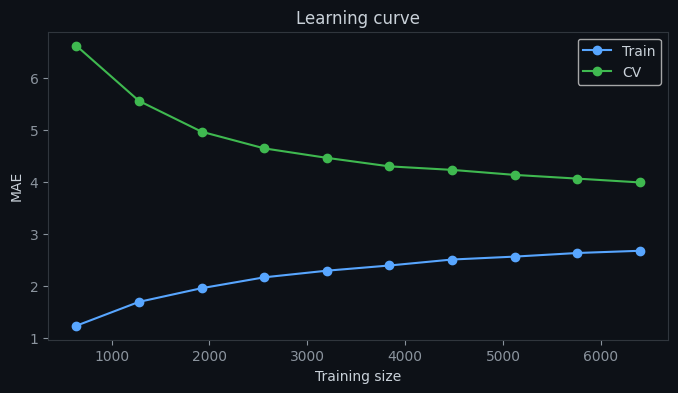

In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(**best_params, random_state=42, device="cuda"),
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, -train_scores.mean(axis=1), "o-", label="Train", color="#58a6ff")
plt.plot(train_sizes, -val_scores.mean(axis=1), "o-", label="CV", color="#3fb950")
plt.xlabel("Training size")
plt.ylabel("MAE")
plt.title("Learning curve")
plt.legend()
save_fig("learning_curve")


  Saved: plots/residuals_2026-05-28_12-52.png
Test MAE: 3.9252  R2: 0.9811
MAE by category:
  study: 4.19 (n=299)
  health: 3.27 (n=232)
  work: 4.45 (n=509)
  errand: 2.96 (n=301)
  personal: 3.19 (n=451)
  social: 5.98 (n=208)


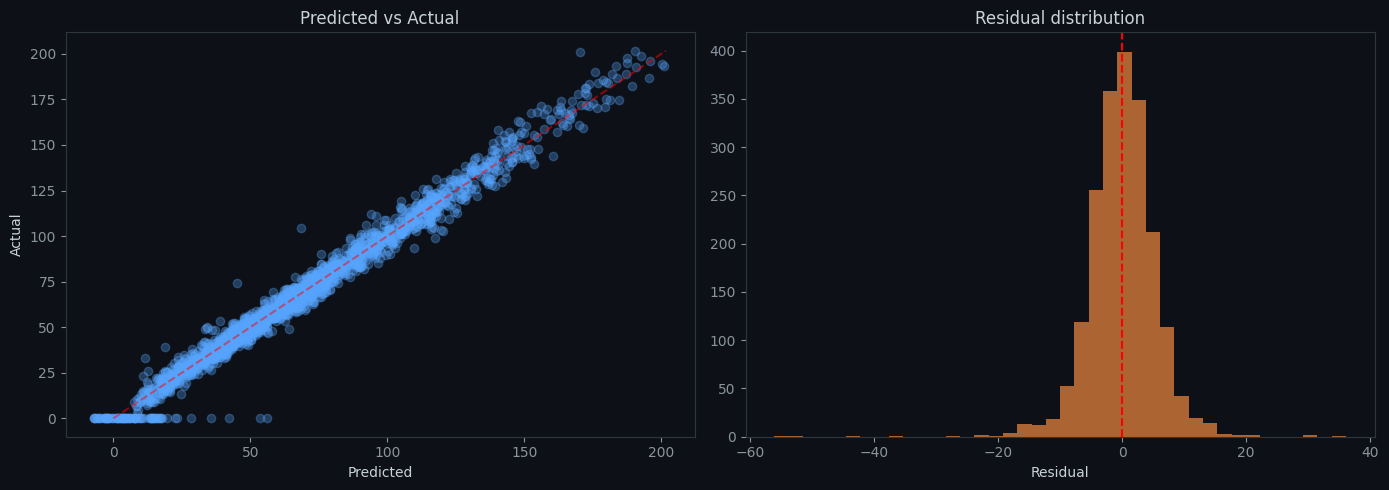

In [19]:
model = xgb.XGBRegressor(**best_params, random_state=42, device="cuda")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, y_test, alpha=0.3, color="#58a6ff")
axes[0].plot([0, y_test.max()], [0, y_test.max()], "r--", alpha=0.5)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Predicted vs Actual")

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color="#f0883e", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")

plt.tight_layout()
save_fig("residuals")

print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}  "
      f"R2: {r2_score(y_test, y_pred):.4f}")

test_cats = train.iloc[y_test.index]["category"].values
print("MAE by category:")

for c in train["category"].unique():
    mask = test_cats == c
    if mask.sum():
        print(f"  {c}: {mean_absolute_error(y_test.values[mask], y_pred[mask]):.2f} "
              f"(n={mask.sum()})")


  Saved: plots/feature_importance_2026-05-28_12-52.png


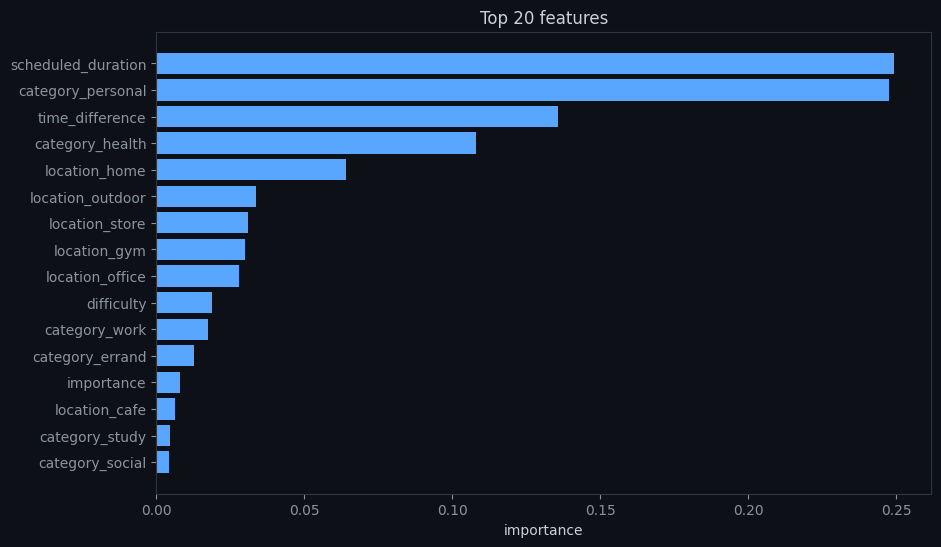

In [21]:
importances = model.feature_importances_
n = min(20, len(importances))
idx = np.argsort(importances)[::-1][:n]

plt.figure(figsize=(10, 6))
plt.barh(range(n), importances[idx][::-1], color="#58a6ff")
plt.yticks(range(n), [feat_names[i] for i in idx][::-1])
plt.xlabel("importance")
plt.title("Top 20 features")
save_fig("feature_importance")


In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
maes = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_proc)):
    X_tr_f, X_val_f = X_proc[tr_idx], X_proc[val_idx]
    y_tr_f, y_val_f = y.iloc[tr_idx], y.iloc[val_idx]

    m = xgb.XGBRegressor(**best_params, random_state=42, device="cuda")
    m.fit(X_tr_f, y_tr_f)
    p = m.predict(X_val_f)

    mae = mean_absolute_error(y_val_f, p)
    maes.append(mae)
    print(f"  Fold {fold + 1}: MAE={mae:.4f}  R2={r2_score(y_val_f, p):.4f}")

print(f"5-Fold CV MAE: {np.mean(maes):.4f} +/- {np.std(maes):.4f}")


  Fold 1: MAE=3.8928  R2=0.9809
  Fold 2: MAE=4.0621  R2=0.9739
  Fold 3: MAE=3.7138  R2=0.9817
  Fold 4: MAE=3.8387  R2=0.9814
  Fold 5: MAE=3.8268  R2=0.9792
5-Fold CV MAE: 3.8668 +/- 0.1137


In [24]:
import json

model.fit(X_proc, y)
model.save_model("duration_predictor.ubj")

cat_enc = preprocessor.named_transformers_["cat"].named_steps["encoder"]
cat_info = {
    "categories": {
        f: list(c) for f, c in zip(cat_feats, cat_enc.categories_)
    }
}

with open("duration_info.json", "w") as f:
    json.dump(cat_info, f)

print("Saved duration_predictor.ubj + duration_info.json")
print("-> place both at: models/regressors/")


Saved duration_predictor.ubj + duration_info.json
-> place both at: models/regressors/


In [26]:
from google.colab import files

files.download("duration_predictor.ubj")
files.download("duration_info.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>